In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import init_printing
import sympy as sym
from scipy.integrate import solve_ivp
import networkx as nx

In [2]:
def get_L(A):
    n = A.shape[1]
    D = np.diag([sum(A[i,:]) for i in range(n)]) 
    L = D-A
    return L

def get_Dpin(B,NL,NF):
    Dpin = np.zeros((NF,NF))
    for i in range(NF):
        Dpin[i,i] = sum(B[i,l] for l in range(NL))
    return Dpin

def getM(G,B,NL,NF,kF,kL):
    A = nx.to_numpy_array(G)
    LF = get_L(A)
    Dpin = get_Dpin(B,NL,NF)
    M = kL*np.linalg.inv(kF*LF + kL*Dpin)@B
    return M

In [72]:
NL = 2
NF = 5
kF = 1
kL = 1000

Gcycle = nx.cycle_graph(5)
A = nx.to_numpy_array(Gcycle)

B = np.zeros((NF,NL))

# B index is B[i,l]=1 means follower i gets info from leader l
B[0,0] = 1 #first follower gets info from first leader
#B[0,1] = 1
#B[1,0]=1
B[1,1]=1

#B[2,0]=0
#B[2,1]=1

M =getM(Gcycle,B,NL,NF,kF,kL)
print(M)

[[0.99875312 0.00124688]
 [0.00124688 0.99875312]
 [0.25062344 0.74937656]
 [0.5        0.5       ]
 [0.74937656 0.25062344]]


In [71]:
print(sym.latex(sym.Matrix(M).T))

\left[\begin{matrix}0.9 & 0.1 & 0.3 & 0.5 & 0.7\\0.1 & 0.9 & 0.7 & 0.5 & 0.3\end{matrix}\right]


In [60]:
NL = 2
NF = 5
kF = 1
kL = 1

Gcomplete = nx.complete_graph(5)
A = nx.to_numpy_array(Gcomplete)

B = np.zeros((NF,NL))

# B index is B[i,l]=1 means follower i gets info from leader l
B[0,0] = 1 #first follower gets info from first leader
B[0,1] = 1
B[1,0]=1
B[1,1]=1

#B[2,0]=0
#B[2,1]=1

M =getM(Gcomplete,B,NL,NF,kF,kL)
print(M)

[[0.5 0.5]
 [0.5 0.5]
 [0.5 0.5]
 [0.5 0.5]
 [0.5 0.5]]


In [78]:
NL = 2
NF = 5
kF = 1
kL = 10000

Gcomplete = nx.complete_graph(5)
A = nx.to_numpy_array(Gcomplete)

B = np.zeros((NF,NL))

# B index is B[i,l]=1 means follower i gets info from leader l
B[0,0] = 1 #first follower gets info from first leader
#B[0,1] = 1
#B[1,0]=1
B[1,1]=1

#B[2,0]=0
#B[2,1]=1

M =getM(Gcomplete,B,NL,NF,kF,kL)
print(M)

[[9.99750125e-01 2.49875062e-04]
 [2.49875062e-04 9.99750125e-01]
 [5.00000000e-01 5.00000000e-01]
 [5.00000000e-01 5.00000000e-01]
 [5.00000000e-01 5.00000000e-01]]


In [50]:
print(sym.latex(sym.Matrix(M)))

\left[\begin{matrix}0.583333333333333 & 0.416666666666667\\0.416666666666667 & 0.583333333333333\\0.5 & 0.5\\0.5 & 0.5\\0.5 & 0.5\end{matrix}\right]


In [22]:
NL = 1
NF = 5
kF = 1
kL = 1

Gcycle = nx.cycle_graph(5)
A = nx.to_numpy_array(Gcycle)

B = np.zeros((NF,NL))

# B index is B[i,l]=1 means follower i gets info from leader l
B[0,0] = 1 #first follower gets info from first leader
B[1,0]= 1
#B[1,0]=1
getM(Gcycle,B,NL,NF,kF,kL)

array([[1.],
       [1.],
       [1.],
       [1.],
       [1.]])

In [18]:
r

array([0, 1])

## Part 3

0.24978661367769955


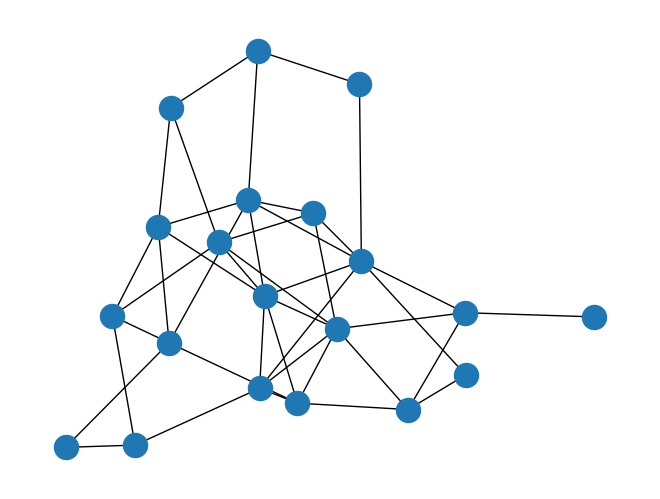

In [ ]:
NF = 20
pcrit = np.log(NF)/NF
#prob_epsilon = 0.01

#pcrit = (1+prob_epsilon)*np.log(NF)/NF
p = pcrit + 0.1
print(p)
Ger = nx.erdos_renyi_graph(NF,p,seed = 10)
#nx.draw(Ger)
Aer= nx.to_numpy_array(Ger)

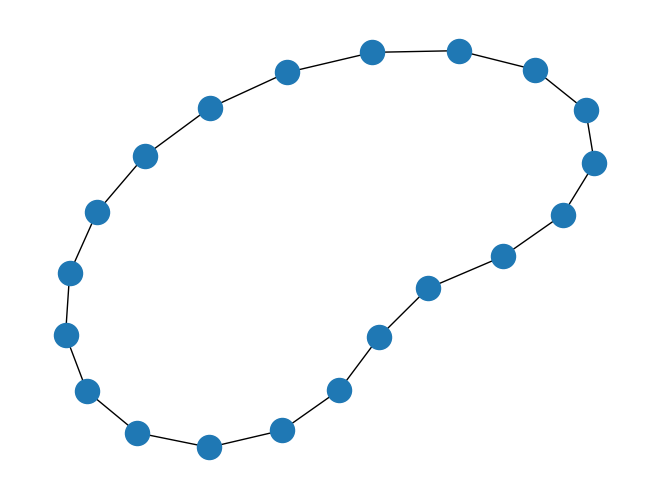

In [173]:
Gcycle = nx.cycle_graph(NF)
Acycle = nx.to_numpy_array(Gcycle)
nx.draw(Gcycle)

In [180]:
NF = 20
pcrit = np.log(NF)/NF
p = pcrit + 0.1
Ger = nx.erdos_renyi_graph(NF,p,seed = 10)
Aer= nx.to_numpy_array(Ger)

Gcycle = nx.cycle_graph(NF)
Acycle = nx.to_numpy_array(Gcycle)

NLlist = [1,3,3]
rlist = [np.array([0]), np.array([0,0,0]), np.array([0.75,0,-0.5])]
A_list = [Acycle, Aer]
G_list = [Gcycle, Ger]
scenarios = [r"$N_L = 1$", r"$N_L = 3$, identitcal", r"$N_L = 3$, heterogeneous"]
graph_labels = ["Cycle", "Erdős–Rényi"]
kF = 1
kL = 1

tspan = (0,3)

t_eval = np.arange(tspan[0],tspan[1],0.05)

def get_solutions(kF,kL):
    solutions = []
    for i, scenario in enumerate(scenarios):
        solutions.append([])
        NL = NLlist[i]
        r = rlist[i]

        for j, graph_label in enumerate(graph_labels):
            G = G_list[j]
            A = A_list[j]
            LF = get_L(A)
            B = np.ones((NF,NL))       
            Dpin = get_Dpin(B,NL,NF)   

            P = kF*LF + kL*Dpin
            M = getM(G,B,NL,NF,kF,kL)
            xeq = M@r                    
            x0 = np.linspace(-1,1,NF)

            def f(t, x):
                return -P@x + kL*B@r

            sol = solve_ivp(f, tspan, x0, t_eval=t_eval)
            solutions[i].append((sol,xeq))
    return solutions

In [181]:
solutions = get_solutions(kF,kL)

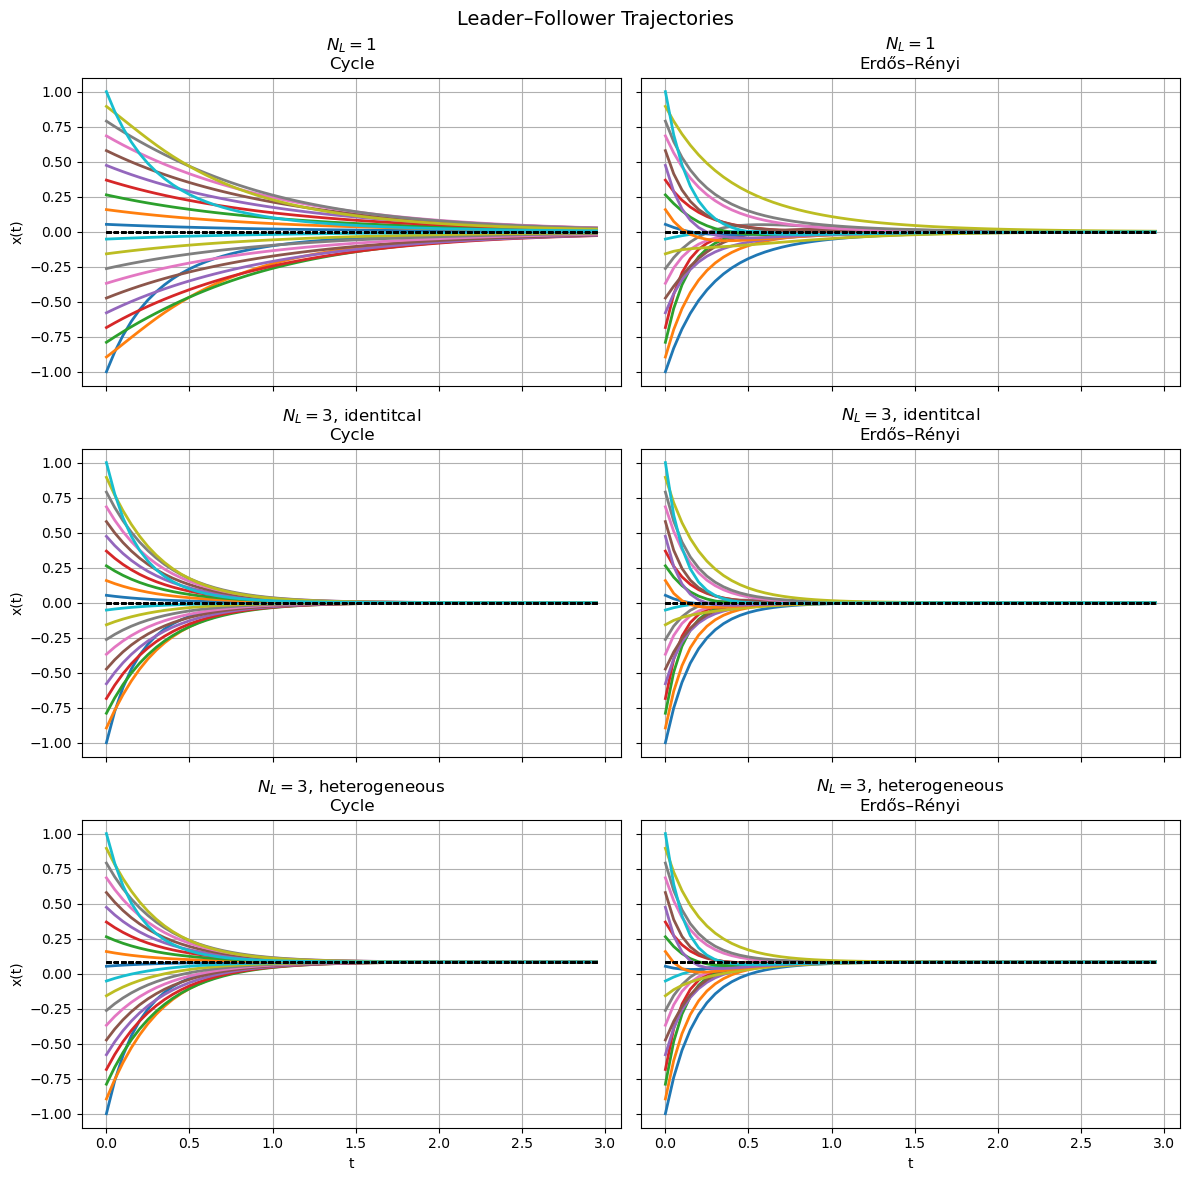

In [184]:
fig, axes = plt.subplots(len(scenarios), len(graph_labels), figsize=(12, 12), sharex=True, sharey=True)

for i, scenario in enumerate(scenarios):
    for j, graph_label in enumerate(graph_labels):
        ax = axes[i, j]
        sol, xeq = solutions[i][j]

        for k in range(sol.y.shape[0]):
            ax.plot(sol.t, sol.y[k], lw=2)

        ax.hlines(xeq,t_eval[0],t_eval[-1],label = 'equlibrium solutions',color = 'black',lw = 1,linestyle="--")

        ax.set_title(f"{scenario}\n{graph_label}")
        ax.grid(True)
        if i == len(scenarios) - 1: # just plot at the bottom to save space
            ax.set_xlabel("t")
        if j == 0:
            ax.set_ylabel("x(t)")

fig.suptitle("Leader–Follower Trajectories", fontsize=14)
plt.tight_layout()
plt.show()

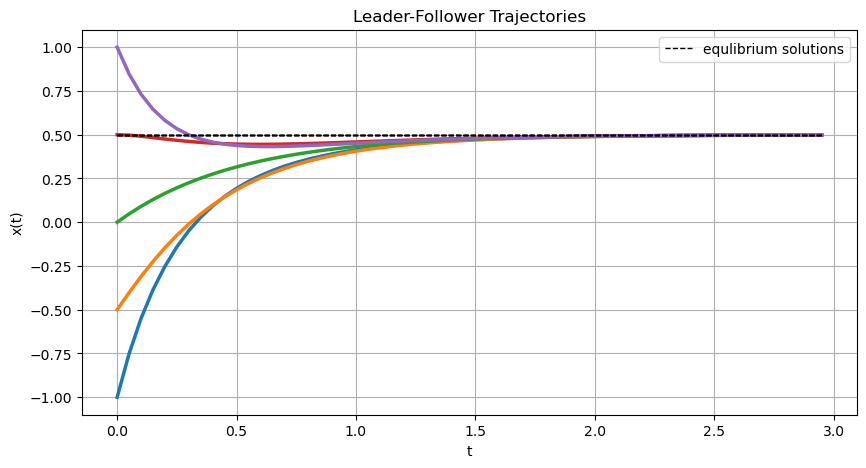

In [161]:
NL = 2
NF = 5
kF = 1
kL = 1

G = nx.cycle_graph(5)
A = nx.to_numpy_array(G)

B = np.ones((NF,NL))
Dpin = get_Dpin(B,NL,NF)
LF = get_L(A)
# B index is B[i,l]=1 means follower i gets info from leader l
B[0,0] = 1 #first follower gets info from first leader
B[1,1]=1

r = np.array([0,1])

P = kF*LF + kL*Dpin

M = getM(G,B,NL,NF,kF,kL)

xeq = M@r

x0= np.linspace(-1,1,NF)

def f(t,x):
    return -P@x + kL*B@r

tspan = (0,3)

t_eval = np.arange(tspan[0],tspan[1],0.05)
sol = solve_ivp(f,tspan,x0,t_eval=t_eval)

plt.figure(figsize=(10,5))
for i in range(NF):
    plt.plot(sol.t,sol.y[i],lw = 2.5)
plt.hlines(xeq,t_eval[0],t_eval[-1],label = 'equlibrium solutions',color = 'black',lw = 1,linestyle="--")
plt.grid()
plt.legend()
plt.ylabel("x(t)")
plt.title("Leader-Follower Trajectories")
plt.xlabel("t")
plt.show()

In [52]:
G = nx.barbell_graph(5)

TypeError: barbell_graph() missing 1 required positional argument: 'm2'

In [6]:
M

array([[0.5, 0.5],
       [0.5, 0.5],
       [0.5, 0.5],
       [0.5, 0.5],
       [0.5, 0.5]])

In [7]:
np.arange(-1,1,100)

array([-1])